Best MAE per scenario
                                    scenario          mode   MAE  RMSE
29             S10_transport_all_summarymask  soft_dynamic  2.70  3.89
0                          S1_transport_pm10        static  2.75  3.94
5                 S2_transport_pm10_pm10mask  soft_dynamic  2.75  3.99
6               S3_transport_pm10_pollutants        static  2.73  4.01
11     S4_transport_pm10_pollutants_pm10mask  soft_dynamic  2.70  3.91
12      S5_transport_pm10_pollutants_allmask        static  2.73  3.90
15  S6_transport_pm10_pollutants_summarymask        static  2.84  4.06
18                 S7_transport_pm10_weather        static  2.89  4.12
21                    S8_transport_pm10_rain        static  2.70  3.83
24            S9_transport_pm10_weather_rain        static  2.77  3.96

Best RMSE per scenario
                                    scenario          mode   MAE  RMSE
29             S10_transport_all_summarymask  soft_dynamic  2.70  3.89
0                          S1_t

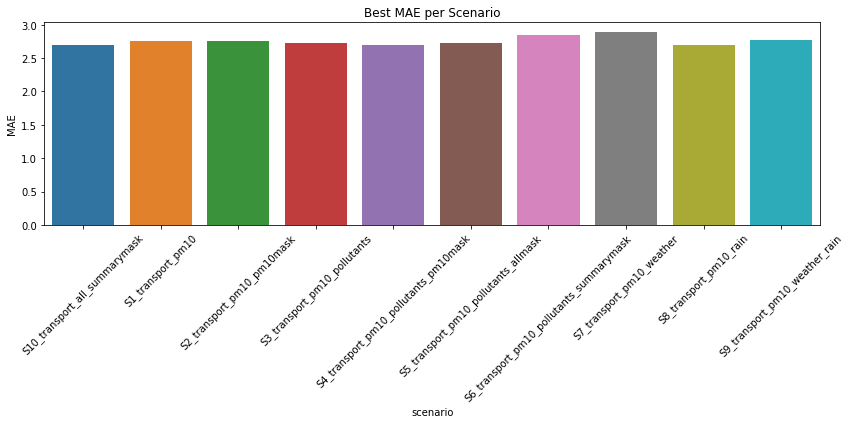

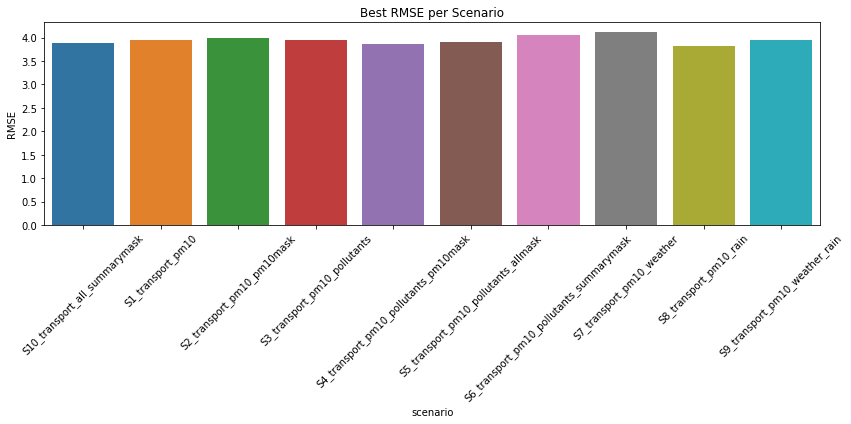

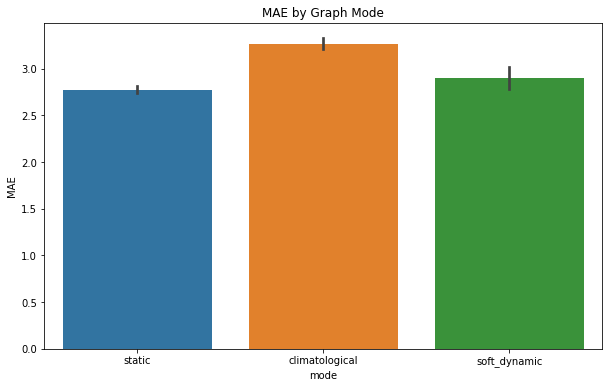

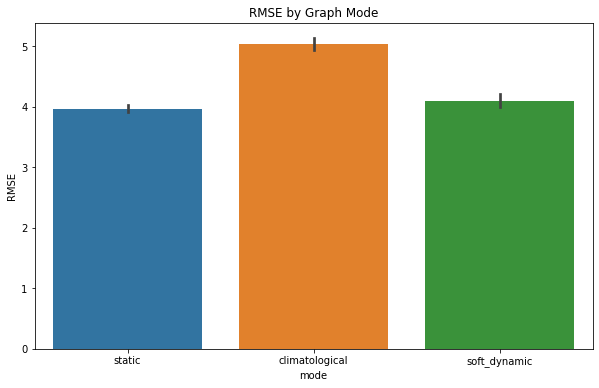

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. 결과 데이터 입력
# -------------------------------
data = [
    ["S1_transport_pm10","static",2.75,3.94],
    ["S1_transport_pm10","climatological",3.44,5.27],
    ["S1_transport_pm10","soft_dynamic",3.07,4.27],

    ["S2_transport_pm10_pm10mask","static",2.84,4.07],
    ["S2_transport_pm10_pm10mask","climatological",3.32,5.24],
    ["S2_transport_pm10_pm10mask","soft_dynamic",2.75,3.99],

    ["S3_transport_pm10_pollutants","static",2.73,4.01],
    ["S3_transport_pm10_pollutants","climatological",3.25,5.03],
    ["S3_transport_pm10_pollutants","soft_dynamic",2.75,3.96],

    ["S4_transport_pm10_pollutants_pm10mask","static",2.71,3.86],
    ["S4_transport_pm10_pollutants_pm10mask","climatological",3.16,4.91],
    ["S4_transport_pm10_pollutants_pm10mask","soft_dynamic",2.70,3.91],

    ["S5_transport_pm10_pollutants_allmask","static",2.73,3.90],
    ["S5_transport_pm10_pollutants_allmask","climatological",3.16,4.93],
    ["S5_transport_pm10_pollutants_allmask","soft_dynamic",2.97,4.16],

    ["S6_transport_pm10_pollutants_summarymask","static",2.84,4.06],
    ["S6_transport_pm10_pollutants_summarymask","climatological",3.28,5.03],
    ["S6_transport_pm10_pollutants_summarymask","soft_dynamic",3.01,4.17],

    ["S7_transport_pm10_weather","static",2.89,4.12],
    ["S7_transport_pm10_weather","climatological",3.37,5.13],
    ["S7_transport_pm10_weather","soft_dynamic",3.25,4.39],

    ["S8_transport_pm10_rain","static",2.70,3.83],
    ["S8_transport_pm10_rain","climatological",3.30,5.20],
    ["S8_transport_pm10_rain","soft_dynamic",2.81,4.02],

    ["S9_transport_pm10_weather_rain","static",2.77,3.96],
    ["S9_transport_pm10_weather_rain","climatological",3.18,4.80],
    ["S9_transport_pm10_weather_rain","soft_dynamic",3.01,4.26],

    ["S10_transport_all_summarymask","static",2.80,3.93],
    ["S10_transport_all_summarymask","climatological",3.21,4.78],
    ["S10_transport_all_summarymask","soft_dynamic",2.70,3.89],
]

df = pd.DataFrame(data, columns=["scenario", "mode", "MAE", "RMSE"])

# -------------------------------
# 2. CSV 저장
# -------------------------------
df.to_csv("results.csv", index=False, encoding="utf-8-sig")

# -------------------------------
# 3. 시나리오별 best 성능
# -------------------------------
best_mae = df.loc[df.groupby("scenario")["MAE"].idxmin()]
best_rmse = df.loc[df.groupby("scenario")["RMSE"].idxmin()]

print("Best MAE per scenario")
print(best_mae)

print("\nBest RMSE per scenario")
print(best_rmse)

# -------------------------------
# 4. 전체 최상위
# -------------------------------
print("\n=== GLOBAL BEST ===")
print("Best MAE:", df.loc[df["MAE"].idxmin()])
print("Best RMSE:", df.loc[df["RMSE"].idxmin()])

# -------------------------------
# 5. 시각화
# -------------------------------
plt.figure(figsize=(12,6))

sns.barplot(data=best_mae, x="scenario", y="MAE")
plt.xticks(rotation=45)
plt.title("Best MAE per Scenario")
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,6))

sns.barplot(data=best_rmse, x="scenario", y="RMSE")
plt.xticks(rotation=45)
plt.title("Best RMSE per Scenario")
plt.tight_layout()
plt.show()

# -------------------------------
# 6. mode별 비교
# -------------------------------
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="mode", y="MAE")
plt.title("MAE by Graph Mode")
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="mode", y="RMSE")
plt.title("RMSE by Graph Mode")
plt.show()

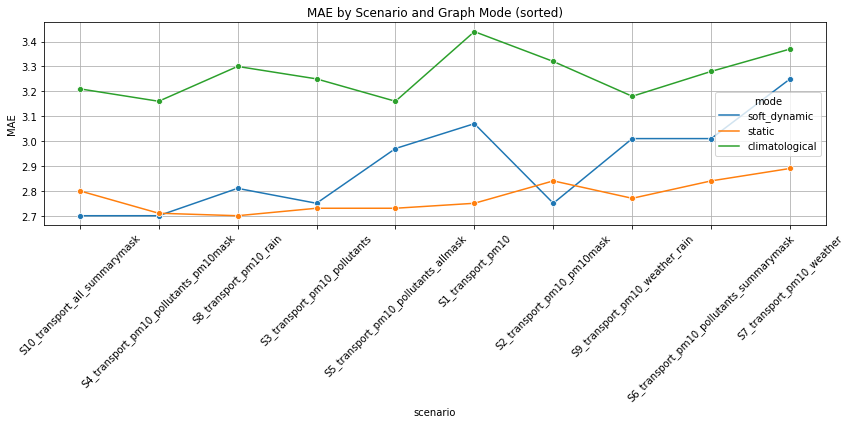

In [2]:
# scenario별 best MAE 기준 오름차순 순서
order = (
    df.loc[df.groupby("scenario")["MAE"].idxmin()]
    .sort_values("MAE")["scenario"]
    .tolist()
)

# scenario 컬럼에 순서 부여
df_plot = df.copy()
df_plot["scenario"] = pd.Categorical(
    df_plot["scenario"],
    categories=order,
    ordered=True
)

df_plot = df_plot.sort_values("scenario")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_plot,
    x="scenario",
    y="MAE",
    hue="mode",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("MAE by Scenario and Graph Mode (sorted)")
plt.grid(True)
plt.tight_layout()
plt.show()

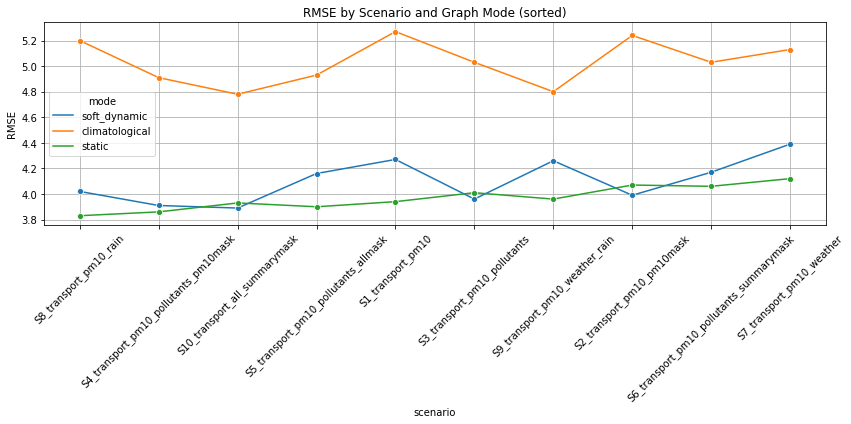

In [3]:
# scenario별 best MAE 기준 오름차순 순서
order = (
    df.loc[df.groupby("scenario")["RMSE"].idxmin()]
    .sort_values("RMSE")["scenario"]
    .tolist()
)

# scenario 컬럼에 순서 부여
df_plot = df.copy()
df_plot["scenario"] = pd.Categorical(
    df_plot["scenario"],
    categories=order,
    ordered=True
)

df_plot = df_plot.sort_values("scenario")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_plot,
    x="scenario",
    y="RMSE",
    hue="mode",
    marker="o"
)

plt.xticks(rotation=45)
plt.title("RMSE by Scenario and Graph Mode (sorted)")
plt.grid(True)
plt.tight_layout()
plt.show()

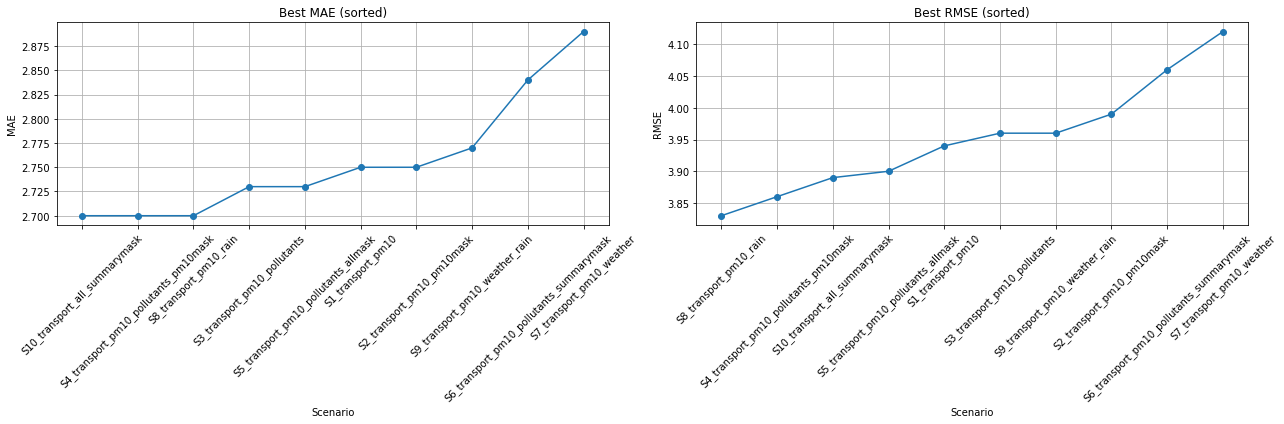

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. best 기준 데이터 만들기
# -------------------------------
best_mae = df.loc[df.groupby("scenario")["MAE"].idxmin()]
best_rmse = df.loc[df.groupby("scenario")["RMSE"].idxmin()]

# -------------------------------
# 2. 오름차순 정렬
# -------------------------------
best_mae = best_mae.sort_values("MAE")
best_rmse = best_rmse.sort_values("RMSE")

# -------------------------------
# 3. subplot 생성
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# -------------------------------
# 4. MAE plot
# -------------------------------
axes[0].plot(best_mae["scenario"], best_mae["MAE"], marker="o")
axes[0].set_title("Best MAE (sorted)")
axes[0].set_xlabel("Scenario")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

# -------------------------------
# 5. RMSE plot
# -------------------------------
axes[1].plot(best_rmse["scenario"], best_rmse["RMSE"], marker="o")
axes[1].set_title("Best RMSE (sorted)")
axes[1].set_xlabel("Scenario")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)

plt.tight_layout()
plt.show()